<a href="https://colab.research.google.com/github/Leonanda1013/DataLoverz/blob/main/Competition/FindIT/Yolo_EfficientNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Set Up

In [ ]:
!pip install ultralytics

In [51]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from ultralytics import YOLO

# gunakan model ringan dulu
yolo_model = YOLO("yolov8n.pt")

import cv2
import numpy as np
import os
from tqdm import tqdm

from sklearn.model_selection import train_test_split

import torchvision.transforms as T

from torch.utils.data import DataLoader
import torch
import torchvision
from torch.utils.data import Dataset
from PIL import Image

import torch.nn as nn
import timm



In [53]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Load Dataset

In [2]:

def load_train_dataset(train_path, limit=None):
    """
    Load dataset train (multiclass folder)

    Parameter:
        train_path: path ke folder train
        limit: max gambar per class (None = semua)

    Return:
        image_paths: list path gambar
        labels: list label_id
        label_to_id: mapping label -> int
    """

    train_path = Path(train_path)

    class_dirs = sorted([d for d in train_path.iterdir() if d.is_dir()])

    label_to_id = {cls.name: idx for idx, cls in enumerate(class_dirs)}

    image_paths = []
    labels = []

    for cls in class_dirs:
        label_name = cls.name
        label_id = label_to_id[label_name]

        image_files = (
            list(cls.glob("*.jpg")) +
            list(cls.glob("*.png")) +
            list(cls.glob("*.jpeg"))
        )

        if limit:
            image_files = image_files[:limit]

        for img_path in image_files:
            image_paths.append(str(img_path))
            labels.append(label_id)

    return image_paths, labels, label_to_id

In [3]:
def load_test_dataset(test_path):
    """
    Load dataset test (tanpa label)

    Parameter:
        test_path: path ke folder test

    Return:
        image_paths: list path gambar
        image_ids: nama file (untuk submission)
    """

    test_path = Path(test_path)

    image_files = (
        list(test_path.glob("*.jpg")) +
        list(test_path.glob("*.png")) +
        list(test_path.glob("*.jpeg"))
    )

    image_paths = [str(p) for p in image_files]
    image_ids = [p.stem for p in image_files]  # nama tanpa extension

    return image_paths, image_ids

In [4]:

def build_train_df(image_paths, labels):
    return pd.DataFrame({
        "path": image_paths,
        "label": labels
    })

def build_test_df(image_paths, image_ids):
    return pd.DataFrame({
        "path": image_paths,
        "id": image_ids
    })

coba

In [5]:
train_paths, train_labels, label_map = load_train_dataset(
    train_path="/content/drive/MyDrive/DATASET/data-analytics-competition-dac-find-it-2026/train",
    limit=None
)

test_paths, test_ids = load_test_dataset(
    test_path="/content/drive/MyDrive/DATASET/data-analytics-competition-dac-find-it-2026/test"
)

train_df = build_train_df(train_paths, train_labels)
test_df  = build_test_df(test_paths, test_ids)

print(label_map)
print(train_df.head())
print(test_df.head())

{'fake_mannequin': 0, 'fake_mask': 1, 'fake_printed': 2, 'fake_screen': 3, 'fake_unknown': 4, 'realperson': 5}
                                                path  label
0  /content/drive/MyDrive/DATASET/data-analytics-...      0
1  /content/drive/MyDrive/DATASET/data-analytics-...      0
2  /content/drive/MyDrive/DATASET/data-analytics-...      0
3  /content/drive/MyDrive/DATASET/data-analytics-...      0
4  /content/drive/MyDrive/DATASET/data-analytics-...      0
                                                path        id
0  /content/drive/MyDrive/DATASET/data-analytics-...  test_004
1  /content/drive/MyDrive/DATASET/data-analytics-...  test_005
2  /content/drive/MyDrive/DATASET/data-analytics-...  test_003
3  /content/drive/MyDrive/DATASET/data-analytics-...  test_001
4  /content/drive/MyDrive/DATASET/data-analytics-...  test_008


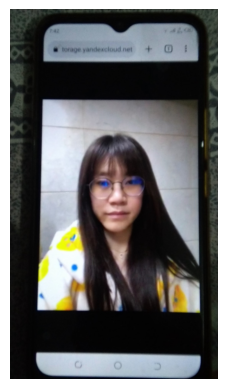

In [11]:

def show_image(path):
    img = Image.open(path).convert("RGB")
    plt.imshow(img)
    plt.axis("off")
    plt.show()

# contoh
show_image(train_df.loc[700, "path"])

In [14]:
train_df.tail(700)

,path,label
767,/content/drive/MyDrive/DATASET/data-analytics-...,4
768,/content/drive/MyDrive/DATASET/data-analytics-...,4
769,/content/drive/MyDrive/DATASET/data-analytics-...,4
770,/content/drive/MyDrive/DATASET/data-analytics-...,4
771,/content/drive/MyDrive/DATASET/data-analytics-...,4
...,...,...
1462,/content/drive/MyDrive/DATASET/data-analytics-...,5
1463,/content/drive/MyDrive/DATASET/data-analytics-...,5
1464,/content/drive/MyDrive/DATASET/data-analytics-...,5
1465,/content/drive/MyDrive/DATASET/data-analytics-...,5


# Deteksi Wajah

In [18]:
def detect_and_crop_face(
    image_path,
    model,
    conf=0.3,
    pad=0.1,
    target_size=None,
    fallback=True
):
    """
    Detect dan crop wajah dari gambar

    Parameter:
        image_path: path gambar
        model: YOLO model
        conf: confidence threshold
        pad: margin bbox (0.1 = 10%)
        target_size: resize (misal (224,224))
        fallback: jika gagal detect, pakai full image

    Return:
        cropped_face (numpy array)
    """

    img = cv2.imread(image_path)
    h, w, _ = img.shape

    results = model(img, conf=conf, verbose=False)[0]

    # tidak ada deteksi
    if len(results.boxes) == 0:
        if fallback:
            face = img
        else:
            return None
    else:
        # ambil bbox terbesar (best practice untuk face)
        boxes = results.boxes.xyxy.cpu().numpy()

        areas = (boxes[:,2] - boxes[:,0]) * (boxes[:,3] - boxes[:,1])
        idx = np.argmax(areas)

        x1, y1, x2, y2 = boxes[idx]

        # tambah padding
        bw = x2 - x1
        bh = y2 - y1

        x1 = int(max(0, x1 - pad * bw))
        y1 = int(max(0, y1 - pad * bh))
        x2 = int(min(w, x2 + pad * bw))
        y2 = int(min(h, y2 + pad * bh))

        face = img[y1:y2, x1:x2]

    # resize opsional
    if target_size:
        face = cv2.resize(face, target_size)

    return face

In [20]:
def process_dataset(df, save_dir, model):
    os.makedirs(save_dir, exist_ok=True)

    new_paths = []

    for i, row in tqdm(df.iterrows(), total=len(df)):
        img_path = row["path"]

        face = detect_and_crop_face(
            img_path,
            model=model,
            pad=0.15,
            target_size=(224,224)
        )

        save_path = os.path.join(save_dir, f"{i}.jpg")
        cv2.imwrite(save_path, face)

        new_paths.append(save_path)

    df["face_path"] = new_paths
    return df

coba

In [21]:
train_df = process_dataset(
    train_df,
    save_dir="/content/drive/MyDrive/faces/train",
    model=yolo_model
)

100%|██████████| 1467/1467 [12:40<00:00,  1.93it/s]


In [23]:
train_df.head()

,path,label,face_path
0,/content/drive/MyDrive/DATASET/data-analytics-...,0,/content/drive/MyDrive/faces/train/0.jpg
1,/content/drive/MyDrive/DATASET/data-analytics-...,0,/content/drive/MyDrive/faces/train/1.jpg
2,/content/drive/MyDrive/DATASET/data-analytics-...,0,/content/drive/MyDrive/faces/train/2.jpg
3,/content/drive/MyDrive/DATASET/data-analytics-...,0,/content/drive/MyDrive/faces/train/3.jpg
4,/content/drive/MyDrive/DATASET/data-analytics-...,0,/content/drive/MyDrive/faces/train/4.jpg


# Augmentasi

In [29]:
train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df["label"],  # penting biar balance
    random_state=42
)

In [36]:
train_tf = T.Compose([
    T.Resize((224,224)),

    # spatial
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(10),

    # photometric
    T.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.1,
        hue=0.05
    ),

    # noise
    T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),

    T.ToTensor(),  # ← koma di sini
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_tf = T.Compose([
    T.Resize((224,224)),
    T.ToTensor(),  # ← koma di sini
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [37]:
class FaceDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = Image.open(row["face_path"]).convert("RGB")
        label = row["label"]

        if self.transform:
            img = self.transform(img)

        return img, label

In [38]:
train_ds = FaceDataset(train_df, transform=train_tf)
val_ds   = FaceDataset(val_df, transform=val_tf)

In [39]:
print(len(train_df), len(val_df))
print(train_df["label"].value_counts())
print(val_df["label"].value_counts())

1173 294
label
5    327
4    247
1    201
0    166
3    155
2     77
Name: count, dtype: int64
label
5    82
4    62
1    51
0    41
3    39
2    19
Name: count, dtype: int64


data louder

In [40]:
train_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=False
)

val_loader = DataLoader(
    val_ds,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=False
)

modelling

In [41]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = timm.create_model(
    "efficientnet_b0",
    pretrained=True,
    num_classes=6
).to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

In [42]:
criterion = nn.CrossEntropyLoss()

In [43]:
import torch.optim as optim

optimizer = optim.AdamW(model.parameters(), lr=1e-4)

In [44]:
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0

    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [45]:
def validate(model, loader):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = correct / total
    return total_loss / len(loader), acc

In [46]:
epochs = 10

for epoch in range(epochs):
    train_loss = train_one_epoch(model, train_loader)
    val_loss, val_acc = validate(model, val_loader)

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 1
Train Loss: 1.9078
Val Loss: 1.1687 | Val Acc: 0.6735
Epoch 2
Train Loss: 0.6569
Val Loss: 0.8346 | Val Acc: 0.7823
Epoch 3
Train Loss: 0.3291
Val Loss: 0.7793 | Val Acc: 0.7993
Epoch 4
Train Loss: 0.2232
Val Loss: 0.6790 | Val Acc: 0.8469
Epoch 5
Train Loss: 0.1543
Val Loss: 0.6713 | Val Acc: 0.8537
Epoch 6
Train Loss: 0.1409
Val Loss: 0.6209 | Val Acc: 0.8537
Epoch 7
Train Loss: 0.0941
Val Loss: 0.5827 | Val Acc: 0.8503
Epoch 8
Train Loss: 0.0794
Val Loss: 0.5542 | Val Acc: 0.8776
Epoch 9
Train Loss: 0.0680
Val Loss: 0.5591 | Val Acc: 0.8776
Epoch 10
Train Loss: 0.0689
Val Loss: 0.5285 | Val Acc: 0.8844


In [48]:
best_acc = 0
if val_acc > best_acc:
    best_acc = val_acc
    torch.save(model.state_dict(), "best_model.pth")

# To Submit

In [68]:
import torch
import timm

device = "cuda" if torch.cuda.is_available() else "cpu"

model = timm.create_model(
    "efficientnet_b0",
    pretrained=False,
    num_classes=6
)

model.load_state_dict(torch.load("best_model.pth", map_location=device))
model = model.to(device)
model.eval()

EfficientNet(
  (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (bn1): BatchNormAct2d(
          32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2

In [55]:
import torchvision.transforms as T

test_tf = T.Compose([
    T.Resize((224,224)),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [56]:
from torch.utils.data import Dataset
from PIL import Image

class TestDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = Image.open(row["face_path"]).convert("RGB")
        img_id = row["id"]

        if self.transform:
            img = self.transform(img)

        return img, img_id

In [60]:
test_df = process_dataset(
    test_df,
    save_dir="/content/drive/MyDrive/faces/test",
    model=yolo_model
)

100%|██████████| 404/404 [03:40<00:00,  1.83it/s]


In [69]:
test_ds = TestDataset(test_df, transform=test_tf)

test_loader = DataLoader(
    test_ds,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

In [70]:
print(test_df.columns)

Index(['path', 'id', 'face_path'], dtype='object')


In [66]:
row = test_df.iloc[0]
img = Image.open(row["face_path"]).convert("RGB")

In [71]:
import numpy as np

preds = []
ids = []

with torch.no_grad():
    for imgs, img_ids in test_loader:
        imgs = imgs.to(device)

        outputs = model(imgs)
        pred = outputs.argmax(1).cpu().numpy()

        preds.extend(pred)
        ids.extend(img_ids)

In [72]:
print(len(preds), len(ids), len(test_df))
print(set(preds))  # harus 0–5

404 404 404
{np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)}


In [73]:
id_to_label = {v: k for k, v in label_map.items()}
pred_labels = [id_to_label[p] for p in preds]

In [76]:
import pandas as pd

submission = pd.DataFrame({
    "id": ids,
    "label": pred_labels
})
submission = submission.sort_values(by="id").reset_index(drop=True)

submission.to_csv("submission.csv", index=False)

In [77]:
print(submission.head())
print(submission.shape)

         id           label
0  test_001     fake_screen
1  test_002  fake_mannequin
2  test_003      realperson
3  test_004    fake_unknown
4  test_005    fake_printed
(404, 2)
